# Rebase Series Example (pandas)

In [1]:
import yfinance as yf

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, Volume, LinePlot
from mplchart.indicators import SMA, RSI, MACD
from mplchart.utils import normalize_prices

In [2]:
ticker = "AAPL"
aapl = normalize_prices(yf.Ticker(ticker).history(period="5y"))
aapl

,open,high,low,close,volume,dividends,stock splits
date,,,,,,,
2021-07-19 00:00:00-04:00,140.120574,140.432502,138.093088,138.853394,121434600,0.0,0.0
2021-07-20 00:00:00-04:00,139.837936,143.386033,139.350560,142.460007,96350000,0.0,0.0
2021-07-21 00:00:00-04:00,141.855635,142.440492,140.978364,141.728912,74993500,0.0,0.0
2021-07-22 00:00:00-04:00,142.255310,144.458244,142.128588,143.093597,77338200,0.0,0.0
2021-07-23 00:00:00-04:00,143.824634,144.965092,143.210535,144.809128,71447400,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-13 00:00:00-04:00,317.019989,323.450012,315.779999,317.309998,43257800,0.0,0.0
2026-07-14 00:00:00-04:00,313.760010,316.190002,311.910004,314.859985,36336800,0.0,0.0
2026-07-15 00:00:00-04:00,317.619995,328.730011,317.320007,327.500000,60957600,0.0,0.0


In [3]:
ticker = "MSFT"
msft = normalize_prices(yf.Ticker(ticker).history(period="5y"))
msft

,open,high,low,close,volume,dividends,stock splits
date,,,,,,,
2021-07-19 00:00:00-04:00,267.688213,269.070179,263.388790,265.845612,32935600,0.0,0.0
2021-07-20 00:00:00-04:00,266.824453,269.645963,265.125800,268.062469,26259700,0.0,0.0
2021-07-21 00:00:00-04:00,267.659413,270.173814,266.114315,270.058655,24364300,0.0,0.0
2021-07-22 00:00:00-04:00,272.400315,274.876349,271.997259,274.607635,23384100,0.0,0.0
2021-07-23 00:00:00-04:00,275.787950,278.302350,274.953019,277.995270,22768100,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-13 00:00:00-04:00,387.750000,393.649994,384.149994,390.989990,28914900,0.0,0.0
2026-07-14 00:00:00-04:00,382.820007,388.190002,378.649994,384.929993,27863900,0.0,0.0
2026-07-15 00:00:00-04:00,387.799988,398.959991,386.399994,395.630005,36253700,0.0,0.0


In [4]:
from mplchart.pandas import merge_prices

prices = merge_prices(aapl, msft=msft.close, rebase=True)
prices


,open,high,low,close,volume,dividends,stock splits,msft
date,,,,,,,,
2021-07-19 00:00:00-04:00,140.120574,140.432502,138.093088,138.853394,121434600,0.0,0.0,138.853394
2021-07-20 00:00:00-04:00,139.837936,143.386033,139.350560,142.460007,96350000,0.0,0.0,140.011277
2021-07-21 00:00:00-04:00,141.855635,142.440492,140.978364,141.728912,74993500,0.0,0.0,141.053901
2021-07-22 00:00:00-04:00,142.255310,144.458244,142.128588,143.093597,77338200,0.0,0.0,143.429872
2021-07-23 00:00:00-04:00,143.824634,144.965092,143.210535,144.809128,71447400,0.0,0.0,145.199262
...,...,...,...,...,...,...,...,...
2026-07-13 00:00:00-04:00,317.019989,323.450012,315.779999,317.309998,43257800,0.0,0.0,204.217353
2026-07-14 00:00:00-04:00,313.760010,316.190002,311.910004,314.859985,36336800,0.0,0.0,201.052165
2026-07-15 00:00:00-04:00,317.619995,328.730011,317.320007,327.500000,60957600,0.0,0.0,206.640871


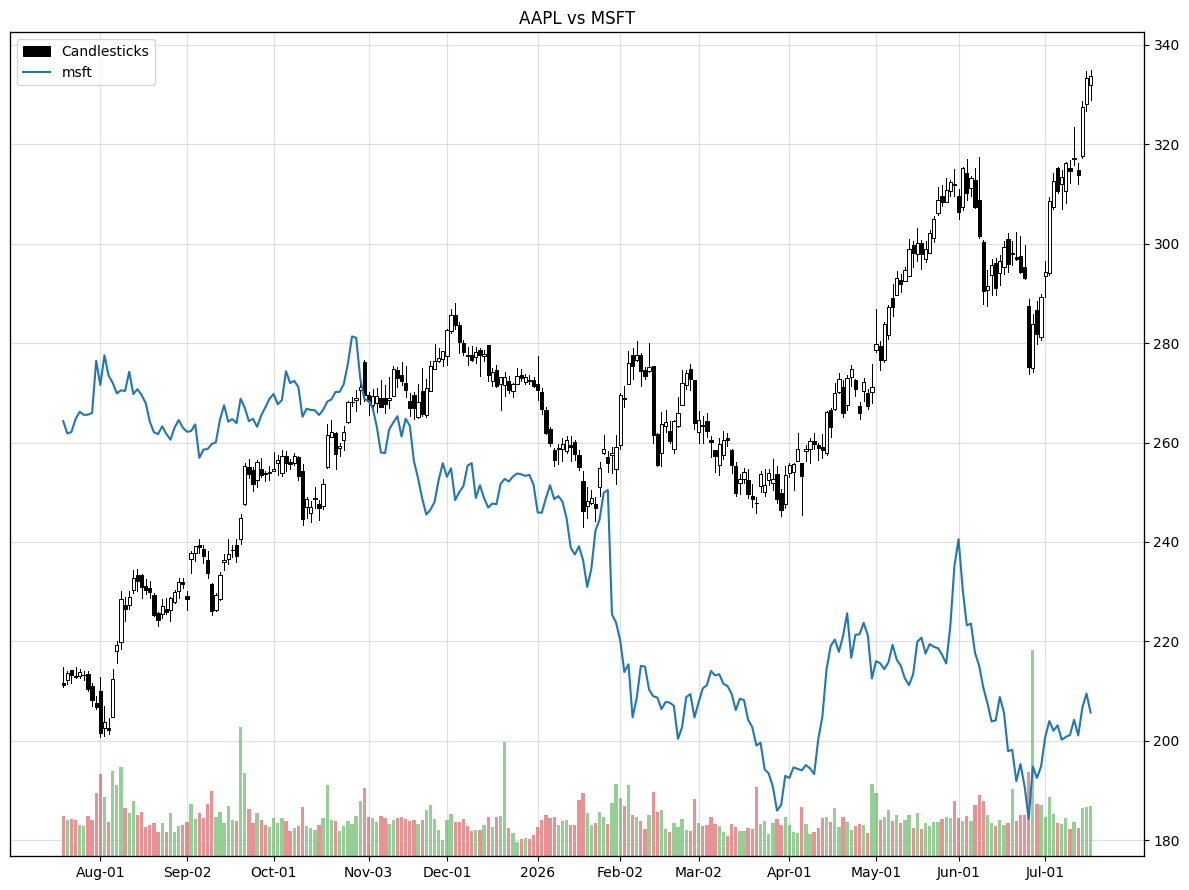

In [5]:
# Plot with merged series 

title = "AAPL vs MSFT"
max_bars = 250

indicators = [
    Candlesticks(),
    LinePlot("msft"),
    Volume(),
]

Chart(prices, title=title, max_bars=max_bars).plot(indicators).show()